## 0. Dipendenze

In [1]:
%pip install -q scikit-learn umap-learn faster-whisper

Note: you may need to restart the kernel to use updated packages.


Impossibile trovare il percorso specificato.


## 1. Setup

In [1]:

from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd()

if not (PROJECT_DIR / "risultati").exists():
    fallback = Path(r"C:\Users\acer\Desktop\ProgettoTesi")
    if fallback.exists():
        PROJECT_DIR = fallback

FEATURE_DIR = PROJECT_DIR / "risultati" / "feature_acustiche_paziente"
TURN_FEATURES_CSV = FEATURE_DIR / "feature_acustiche_turn_level.csv"

OUTPUT_DIR = PROJECT_DIR / "risultati" / "profilazione_acustica"
FIGURE_DIR = OUTPUT_DIR / "figure"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

USE_ASR_ENRICHMENT = True
ASR_MODEL_SIZE = "small"
ASR_LANGUAGE = "it"

ASR_CACHE_CSV = OUTPUT_DIR / "trascrizioni_turni_paziente.csv"

MAX_MISSING_PERCENT = 20.0
CORRELATION_THRESHOLD = 0.90
MAX_TURNS_PER_PATIENT_FIT = 25
K_VALUES = [2, 3, 4, 5, 6]
MIN_CLUSTER_SHARE = 0.08
N_STABILITY_RUNS = 20

print("PROJECT_DIR:", PROJECT_DIR)
print("TURN_FEATURES_CSV:", TURN_FEATURES_CSV)
print("Esiste:", TURN_FEATURES_CSV.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("USE_ASR_ENRICHMENT:", USE_ASR_ENRICHMENT)

if not TURN_FEATURES_CSV.exists():
    raise FileNotFoundError(
        f"File non trovato: {TURN_FEATURES_CSV}\n"
        "Eseguire prima il notebook 10."
    )


PROJECT_DIR: c:\Users\acer\Desktop\ProgettoTesi
TURN_FEATURES_CSV: c:\Users\acer\Desktop\ProgettoTesi\risultati\feature_acustiche_paziente\feature_acustiche_turn_level.csv
Esiste: True
OUTPUT_DIR: c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica
USE_ASR_ENRICHMENT: True


## 2. Caricamento delle feature del notebook 10

In [3]:

turns = pd.read_csv(TURN_FEATURES_CSV)

required = {
    "patient_id",
    "recording_id",
    "turn_id",
    "turn_duration_seconds",
    "audio_path_turn",
    "speech_activity_ratio",
    "internal_pause_mean_seconds",
    "internal_pause_rate_per_min",
    "f0_mean",
    "f0_std",
    "f0_iqr",
    "rms_mean",
    "rms_std",
    "hnr",
    "jitter",
    "shimmer",
}

missing = required - set(turns.columns)
if missing:
    raise ValueError(f"Colonne mancanti: {sorted(missing)}")

turns["patient_id"] = pd.to_numeric(turns["patient_id"], errors="coerce")
turns = turns.dropna(subset=["patient_id", "turn_id"]).copy()
turns["patient_id"] = turns["patient_id"].astype(int)

print("Turni:", len(turns))
print("Pazienti:", turns["patient_id"].nunique())
print("Registrazioni:", turns["recording_id"].nunique())

FORBIDDEN_TERMS = ["dn4", "bpi", "nrs"]

clinical_columns = [
    col for col in turns.columns
    if any(term in str(col).lower() for term in FORBIDDEN_TERMS)
]

print("Colonne cliniche trovate:", clinical_columns)

if clinical_columns:
    raise RuntimeError(
        "Il notebook 11 non deve utilizzare "
        f"variabili cliniche: {clinical_columns}"
    )


Turni: 3825
Pazienti: 90
Registrazioni: 92
Colonne cliniche trovate: []


## 3. Arricchimento ASR: velocità di eloquio ed esitazioni

In [4]:

FILLERS = {"eh", "ehm", "em", "uh", "um", "mh", "mmh", "mmm", "mhm"}

TOKEN_PATTERN = re.compile(
    r"[A-Za-zÀ-ÖØ-öø-ÿ']+",
    flags=re.UNICODE,
)

def tokenize_text(text):
    return [
        token.lower()
        for token in TOKEN_PATTERN.findall(str(text))
    ]

def linguistic_features(text):
    tokens = tokenize_text(text)
    word_count = len(tokens)
    filler_count = sum(token in FILLERS for token in tokens)
    repeated_adjacent = sum(
        tokens[i] == tokens[i - 1]
        for i in range(1, len(tokens))
    )

    return {
        "word_count": int(word_count),
        "filler_count": int(filler_count),
        "repeated_adjacent_word_count": int(repeated_adjacent),
    }

if USE_ASR_ENRICHMENT:
    if ASR_CACHE_CSV.exists():
        asr_df = pd.read_csv(ASR_CACHE_CSV)
        print("Cache ASR caricata:", len(asr_df))
    else:
        from faster_whisper import WhisperModel

        try:
            import torch
            has_cuda = torch.cuda.is_available()
        except Exception:
            has_cuda = False

        asr_device = "cuda" if has_cuda else "cpu"
        compute_type = "float16" if asr_device == "cuda" else "int8"

        print(
            "Caricamento Faster-Whisper:",
            ASR_MODEL_SIZE,
            "| device:",
            asr_device,
            "| compute_type:",
            compute_type,
        )

        asr_model = WhisperModel(
            ASR_MODEL_SIZE,
            device=asr_device,
            compute_type=compute_type,
        )

        asr_rows = []

        for progress, row in enumerate(turns.itertuples(index=False), start=1):
            audio_path = Path(str(row.audio_path_turn))
            text = ""
            error = ""

            if not audio_path.exists():
                error = "audio_missing"
            else:
                try:
                    segments, info = asr_model.transcribe(
                        str(audio_path),
                        language=ASR_LANGUAGE,
                        beam_size=1,
                        vad_filter=False,
                        condition_on_previous_text=False,
                    )

                    text = " ".join(
                        segment.text.strip()
                        for segment in segments
                        if segment.text.strip()
                    ).strip()

                except Exception as exc:
                    error = str(exc)

            lf = linguistic_features(text)

            asr_rows.append({
                "turn_id": str(row.turn_id),
                "transcript": text,
                "asr_error": error,
                **lf,
            })

            if progress % 200 == 0 or progress == len(turns):
                print(
                    f"\rTurni trascritti: {progress}/{len(turns)}",
                    end="",
                )

        print()

        asr_df = pd.DataFrame(asr_rows)
        asr_df.to_csv(ASR_CACHE_CSV, index=False)
        print("Cache salvata:", ASR_CACHE_CSV)

    required_asr = {
        "turn_id",
        "transcript",
        "word_count",
        "filler_count",
        "repeated_adjacent_word_count",
    }

    missing_asr = required_asr - set(asr_df.columns)
    if missing_asr:
        raise ValueError(
            f"Cache ASR incompleta: {sorted(missing_asr)}"
        )

    turns = turns.merge(
        asr_df[
            [
                "turn_id",
                "transcript",
                "asr_error",
                "word_count",
                "filler_count",
                "repeated_adjacent_word_count",
            ]
        ],
        on="turn_id",
        how="left",
        validate="one_to_one",
    )

    duration = pd.to_numeric(
        turns["turn_duration_seconds"],
        errors="coerce",
    )

    active_duration = pd.to_numeric(
        turns["non_silent_duration_seconds"],
        errors="coerce",
    )

    turns["words_per_second"] = (
        turns["word_count"] / duration.replace(0, np.nan)
    )

    turns["words_per_minute"] = (
        turns["words_per_second"] * 60.0
    )

    turns["articulation_words_per_second"] = (
        turns["word_count"]
        / active_duration.replace(0, np.nan)
    )

    turns["filler_rate_per_100_words"] = np.where(
        turns["word_count"] > 0,
        turns["filler_count"] / turns["word_count"] * 100.0,
        np.nan,
    )

    turns["repetition_rate_per_100_words"] = np.where(
        turns["word_count"] > 0,
        turns["repeated_adjacent_word_count"]
        / turns["word_count"] * 100.0,
        np.nan,
    )

    print(
        "Turni con almeno una parola ASR:",
        int((turns["word_count"] > 0).sum()),
        "/",
        len(turns),
    )

    print(
        "Turni con errore ASR:",
        int((turns["asr_error"].fillna("") != "").sum()),
    )
else:
    print("Arricchimento ASR disattivato.")


Cache ASR caricata: 3825
Turni con almeno una parola ASR: 3616 / 3825
Turni con errore ASR: 0


## 4. Definizione del set di feature per il clustering

In [5]:

CORE_FEATURES = [
    "speech_activity_ratio",
    "internal_pause_mean_seconds",
    "internal_pause_max_seconds",
    "internal_pause_rate_per_min",
    "f0_std",
    "f0_iqr",
    "rms_mean",
    "rms_std",
    "hnr",
    "jitter",
    "shimmer",
    "centroid_mean",
    "bandwidth_mean",
    "flatness_mean",
    "zcr_mean",
]

if USE_ASR_ENRICHMENT:
    CORE_FEATURES += [
        "words_per_second",
        "articulation_words_per_second",
        "filler_rate_per_100_words",
        "repetition_rate_per_100_words",
    ]

CORE_FEATURES = [
    feature for feature in CORE_FEATURES
    if feature in turns.columns
]

feature_qc_rows = []

for feature in CORE_FEATURES:
    values = pd.to_numeric(turns[feature], errors="coerce")

    feature_qc_rows.append({
        "feature": feature,
        "n_missing": int(values.isna().sum()),
        "percent_missing": float(100.0 * values.isna().mean()),
        "n_unique_nonmissing": int(values.dropna().nunique()),
        "variance": (
            float(values.var())
            if values.notna().sum() > 1
            else np.nan
        ),
    })

feature_qc = pd.DataFrame(feature_qc_rows)

display(
    feature_qc.sort_values(
        "percent_missing",
        ascending=False,
    )
)

selected_features = (
    feature_qc.loc[
        (feature_qc["percent_missing"] <= MAX_MISSING_PERCENT)
        & (feature_qc["n_unique_nonmissing"] > 1),
        "feature",
    ]
    .tolist()
)

print("Feature core iniziali:", len(CORE_FEATURES))
print("Feature dopo missing/variance QC:", len(selected_features))
print(selected_features)


,feature,n_missing,percent_missing,n_unique_nonmissing,variance
4,f0_std,261,6.823529,3559,130.206522
5,f0_iqr,261,6.823529,3419,409.668164
18,repetition_rate_per_100_words,209,5.464052,41,39.755915
17,filler_rate_per_100_words,209,5.464052,20,74.819378
10,shimmer,2,0.052288,3823,0.000952
0,speech_activity_ratio,0,0.000000,1968,0.007042
1,internal_pause_mean_seconds,0,0.000000,177,0.029737
2,internal_pause_max_seconds,0,0.000000,44,0.052865
7,rms_std,0,0.000000,3825,0.000116
6,rms_mean,0,0.000000,3825,0.000295


Feature core iniziali: 19
Feature dopo missing/variance QC: 19
['speech_activity_ratio', 'internal_pause_mean_seconds', 'internal_pause_max_seconds', 'internal_pause_rate_per_min', 'f0_std', 'f0_iqr', 'rms_mean', 'rms_std', 'hnr', 'jitter', 'shimmer', 'centroid_mean', 'bandwidth_mean', 'flatness_mean', 'zcr_mean', 'words_per_second', 'articulation_words_per_second', 'filler_rate_per_100_words', 'repetition_rate_per_100_words']


## 5. Trasformazioni robuste e rimozione della ridondanza

In [6]:

X_raw = turns[selected_features].apply(
    pd.to_numeric,
    errors="coerce",
)

X_winsor = X_raw.copy()
winsor_limits = {}

for col in X_winsor.columns:
    values = X_winsor[col].dropna()

    if values.empty:
        continue

    low = float(values.quantile(0.01))
    high = float(values.quantile(0.99))

    winsor_limits[col] = {
        "p01": low,
        "p99": high,
    }

    X_winsor[col] = X_winsor[col].clip(
        lower=low,
        upper=high,
    )

LOG_CANDIDATES = [
    "internal_pause_mean_seconds",
    "internal_pause_max_seconds",
    "internal_pause_rate_per_min",
    "jitter",
    "shimmer",
    "filler_rate_per_100_words",
    "repetition_rate_per_100_words",
]

log_applied = []

for col in LOG_CANDIDATES:
    if col not in X_winsor.columns:
        continue

    nonmissing = X_winsor[col].dropna()

    if not nonmissing.empty and nonmissing.min() >= 0:
        X_winsor[col] = np.log1p(X_winsor[col])
        log_applied.append(col)

print("log1p applicato a:", log_applied)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_winsor)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)

scaled_df = pd.DataFrame(
    X_scaled,
    columns=X_winsor.columns,
    index=turns.index,
)

corr = scaled_df.corr(method="spearman").abs()

to_drop = set()
columns = list(corr.columns)

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        col_i = columns[i]
        col_j = columns[j]

        if corr.loc[col_i, col_j] > CORRELATION_THRESHOLD:
            to_drop.add(col_j)

final_features = [
    col for col in columns
    if col not in to_drop
]

print(
    "Feature eliminate per |rho| >",
    CORRELATION_THRESHOLD,
    ":",
    sorted(to_drop),
)

print("Feature finali clustering:", len(final_features))
print(final_features)

X_final_df = X_winsor[final_features].copy()

final_imputer = SimpleImputer(strategy="median")
X_final_imputed = final_imputer.fit_transform(X_final_df)

final_scaler = RobustScaler()
X_final = final_scaler.fit_transform(X_final_imputed)


log1p applicato a: ['internal_pause_mean_seconds', 'internal_pause_max_seconds', 'internal_pause_rate_per_min', 'jitter', 'shimmer', 'filler_rate_per_100_words', 'repetition_rate_per_100_words']
Feature eliminate per |rho| > 0.9 : ['articulation_words_per_second', 'internal_pause_max_seconds', 'internal_pause_rate_per_min', 'rms_std', 'zcr_mean']
Feature finali clustering: 14
['speech_activity_ratio', 'internal_pause_mean_seconds', 'f0_std', 'f0_iqr', 'rms_mean', 'hnr', 'jitter', 'shimmer', 'centroid_mean', 'bandwidth_mean', 'flatness_mean', 'words_per_second', 'filler_rate_per_100_words', 'repetition_rate_per_100_words']


## 6. Campione bilanciato per il fit del clustering

In [7]:

fit_indices = []

for patient_id, group in turns.groupby("patient_id"):
    n = min(
        len(group),
        MAX_TURNS_PER_PATIENT_FIT,
    )

    sampled = group.sample(
        n=n,
        random_state=RANDOM_STATE + int(patient_id),
    )

    fit_indices.extend(sampled.index.tolist())

fit_indices = np.asarray(
    sorted(fit_indices),
    dtype=int,
)

X_fit = X_final[fit_indices]

patient_fit = turns.loc[
    fit_indices,
    "patient_id",
].to_numpy()

print("Turni totali:", len(turns))
print("Turni nel fit bilanciato:", len(fit_indices))
print("Pazienti nel fit:", len(np.unique(patient_fit)))

display(
    turns.loc[fit_indices]
    .groupby("patient_id")
    .size()
    .rename("n_turni_fit")
    .describe()
)


Turni totali: 3825
Turni nel fit bilanciato: 2164
Pazienti nel fit: 90


count    90.000000
mean     24.044444
std       3.115424
min       8.000000
25%      25.000000
50%      25.000000
75%      25.000000
max      25.000000
Name: n_turni_fit, dtype: float64

## 7. Scelta non supervisionata del numero di cluster

In [8]:

cluster_selection_rows = []
models_by_k = {}

for k in K_VALUES:
    model = KMeans(
        n_clusters=k,
        n_init=50,
        random_state=RANDOM_STATE,
    )

    labels_fit = model.fit_predict(X_fit)

    counts = np.bincount(
        labels_fit,
        minlength=k,
    )

    min_share = float(
        counts.min() / len(labels_fit)
    )

    silhouette = silhouette_score(
        X_fit,
        labels_fit,
        metric="euclidean",
    )

    ch = calinski_harabasz_score(
        X_fit,
        labels_fit,
    )

    db = davies_bouldin_score(
        X_fit,
        labels_fit,
    )

    cluster_selection_rows.append({
        "k": k,
        "silhouette": silhouette,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "min_cluster_size": int(counts.min()),
        "max_cluster_size": int(counts.max()),
        "min_cluster_share": min_share,
        "passes_min_cluster_share": (
            min_share >= MIN_CLUSTER_SHARE
        ),
    })

    models_by_k[k] = model

cluster_selection = pd.DataFrame(
    cluster_selection_rows
)

display(
    cluster_selection.round(4)
)

valid_k = cluster_selection[
    cluster_selection[
        "passes_min_cluster_share"
    ]
].copy()

if valid_k.empty:
    print(
        "ATTENZIONE: nessun k soddisfa la "
        "dimensione minima dei cluster."
    )
    valid_k = cluster_selection.copy()

BEST_K = int(
    valid_k.sort_values(
        [
            "silhouette",
            "davies_bouldin",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .iloc[0]["k"]
)

print(
    "BEST_K selezionato senza score clinici:",
    BEST_K
)


,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size,min_cluster_share,passes_min_cluster_share
0,2,0.2039,412.1221,1.8957,525,1639,0.2426,True
1,3,0.1503,400.3438,1.9101,408,884,0.1885,True
2,4,0.1408,367.8481,1.8062,348,729,0.1608,True
3,5,0.1425,332.0607,1.7229,239,672,0.1104,True
4,6,0.1394,309.1533,1.7136,122,602,0.0564,False


BEST_K selezionato senza score clinici: 2


### Stabilità rispetto all'inizializzazione

In [9]:

stability_labels = []

for run in range(N_STABILITY_RUNS):
    model_run = KMeans(
        n_clusters=BEST_K,
        n_init=20,
        random_state=RANDOM_STATE + run,
    )

    stability_labels.append(
        model_run.fit_predict(X_fit)
    )

ari_values = []

for i in range(len(stability_labels)):
    for j in range(i + 1, len(stability_labels)):
        ari_values.append(
            adjusted_rand_score(
                stability_labels[i],
                stability_labels[j],
            )
        )

print(
    "ARI medio tra inizializzazioni:",
    round(float(np.mean(ari_values)), 4),
)

print(
    "ARI minimo:",
    round(float(np.min(ari_values)), 4),
)

print(
    "ARI massimo:",
    round(float(np.max(ari_values)), 4),
)


ARI medio tra inizializzazioni: 0.9762
ARI minimo: 0.9452
ARI massimo: 1.0


## 8. Fit finale e labeling di tutti i turni

In [10]:

final_model = KMeans(
    n_clusters=BEST_K,
    n_init=100,
    random_state=RANDOM_STATE,
)

final_model.fit(X_fit)

all_labels = final_model.predict(X_final)

turns_labeled = turns.copy()

turns_labeled["acoustic_cluster"] = all_labels.astype(int)
turns_labeled["acoustic_label"] = (
    "cluster_"
    + turns_labeled["acoustic_cluster"].astype(str)
)

cluster_counts = (
    turns_labeled["acoustic_label"]
    .value_counts()
    .sort_index()
    .rename("n_turns")
    .to_frame()
)

cluster_counts["share"] = (
    cluster_counts["n_turns"]
    / len(turns_labeled)
)

display(cluster_counts)

TURN_LABELS_CSV = (
    OUTPUT_DIR
    / "turni_con_label_acustica.csv"
)

turns_labeled.to_csv(
    TURN_LABELS_CSV,
    index=False,
)

print("Salvato:", TURN_LABELS_CSV)


,n_turns,share
acoustic_label,,
cluster_0,2888,0.755033
cluster_1,937,0.244967


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\turni_con_label_acustica.csv


## 9. PCA e UMAP dello spazio acustico

Varianza spiegata PCA1+PCA2: 0.4507


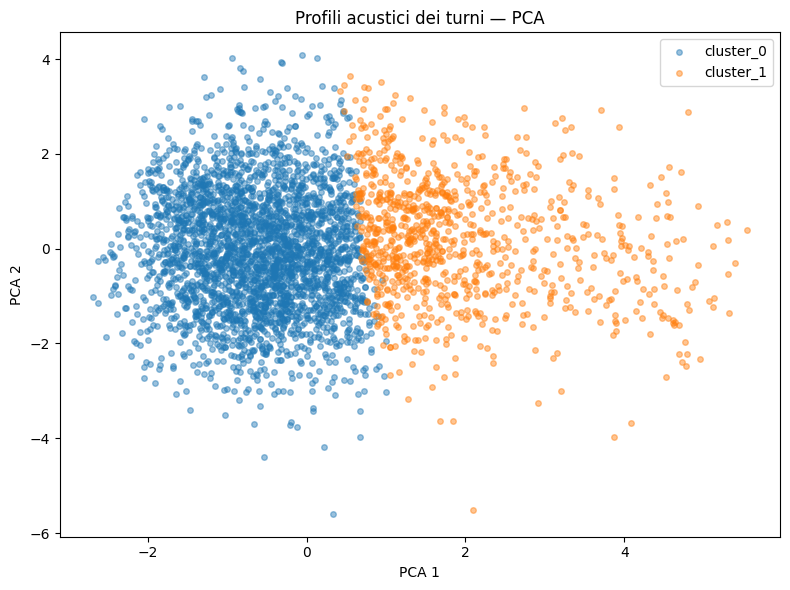

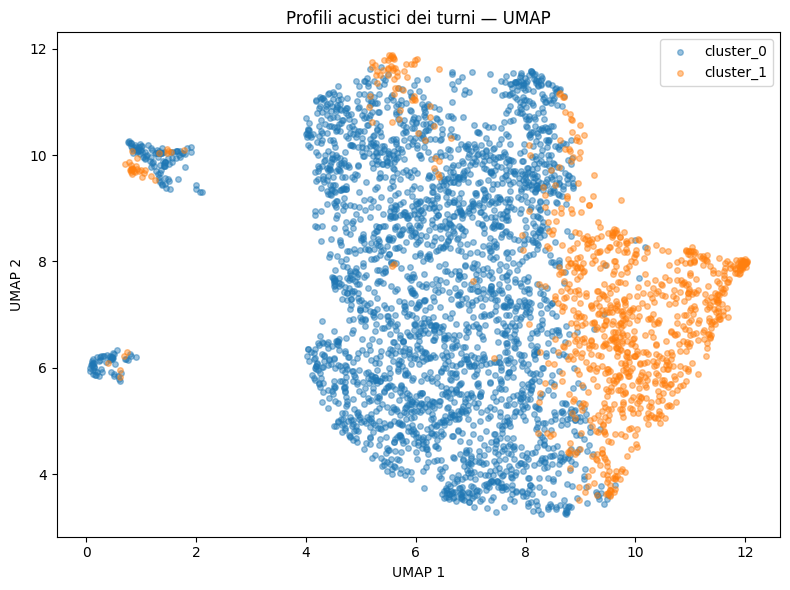

In [11]:

pca = PCA(
    n_components=min(
        10,
        X_final.shape[1],
    ),
    random_state=RANDOM_STATE,
)

pca_values = pca.fit_transform(X_final)

turns_labeled["PCA1"] = pca_values[:, 0]
turns_labeled["PCA2"] = pca_values[:, 1]

print(
    "Varianza spiegata PCA1+PCA2:",
    round(
        float(
            pca.explained_variance_ratio_[:2].sum()
        ),
        4,
    ),
)

plt.figure(figsize=(8, 6))

for label, group in turns_labeled.groupby("acoustic_label"):
    plt.scatter(
        group["PCA1"],
        group["PCA2"],
        s=16,
        alpha=0.45,
        label=label,
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Profili acustici dei turni — PCA")
plt.legend()
plt.tight_layout()

PCA_PNG = FIGURE_DIR / "pca_cluster_acustici.png"
plt.savefig(PCA_PNG, dpi=200)
plt.show()

try:
    import umap

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=20,
        min_dist=0.15,
        metric="euclidean",
        random_state=RANDOM_STATE,
    )

    umap_values = reducer.fit_transform(X_final)

    turns_labeled["UMAP1"] = umap_values[:, 0]
    turns_labeled["UMAP2"] = umap_values[:, 1]

    plt.figure(figsize=(8, 6))

    for label, group in turns_labeled.groupby("acoustic_label"):
        plt.scatter(
            group["UMAP1"],
            group["UMAP2"],
            s=16,
            alpha=0.45,
            label=label,
        )

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("Profili acustici dei turni — UMAP")
    plt.legend()
    plt.tight_layout()

    UMAP_PNG = FIGURE_DIR / "umap_cluster_acustici.png"
    plt.savefig(UMAP_PNG, dpi=200)
    plt.show()

except Exception as exc:
    print("UMAP non generata:", exc)


## 10. Profilo dei cluster

In [12]:

profile_df = pd.DataFrame(
    X_final,
    columns=final_features,
    index=turns_labeled.index,
)

profile_df["acoustic_cluster"] = (
    turns_labeled["acoustic_cluster"].values
)

cluster_profile = (
    profile_df
    .groupby("acoustic_cluster")
    [final_features]
    .mean()
)

display(cluster_profile.round(3))

PROFILE_CSV = (
    OUTPUT_DIR
    / "profilo_standardizzato_cluster.csv"
)

cluster_profile.to_csv(PROFILE_CSV)

top_rows = []

for cluster_id in cluster_profile.index:
    series = (
        cluster_profile
        .loc[cluster_id]
        .sort_values(
            key=lambda x: x.abs(),
            ascending=False,
        )
    )

    for rank, (feature, value) in enumerate(
        series.head(6).items(),
        start=1,
    ):
        top_rows.append({
            "acoustic_cluster": int(cluster_id),
            "rank": rank,
            "feature": feature,
            "standardized_mean": float(value),
            "direction": (
                "alto"
                if value > 0
                else "basso"
            ),
        })

top_features = pd.DataFrame(top_rows)

display(top_features)

TOP_FEATURES_CSV = (
    OUTPUT_DIR
    / "top_feature_per_cluster.csv"
)

top_features.to_csv(
    TOP_FEATURES_CSV,
    index=False,
)


,speech_activity_ratio,internal_pause_mean_seconds,f0_std,f0_iqr,rms_mean,hnr,jitter,shimmer,centroid_mean,bandwidth_mean,flatness_mean,words_per_second,filler_rate_per_100_words,repetition_rate_per_100_words
acoustic_cluster,,,,,,,,,,,,,,
0,-0.342,0.071,0.171,0.256,0.196,0.137,0.093,-0.071,-0.239,-0.253,-0.129,0.070,0.064,0.098
1,-0.264,0.025,-0.088,0.018,0.046,-0.462,0.373,0.092,1.238,0.807,1.572,0.025,0.018,0.106


,acoustic_cluster,rank,feature,standardized_mean,direction
0,0,1,speech_activity_ratio,-0.341500,basso
1,0,2,f0_iqr,0.256208,alto
2,0,3,bandwidth_mean,-0.252714,basso
3,0,4,centroid_mean,-0.238713,basso
4,0,5,rms_mean,0.195586,alto
5,0,6,f0_std,0.170669,alto
6,1,1,flatness_mean,1.571636,alto
7,1,2,centroid_mean,1.238268,alto
8,1,3,bandwidth_mean,0.806956,alto
9,1,4,hnr,-0.461522,basso


## 11. Aggregazione del labeling acustico a livello paziente

In [13]:

patient_rows = []

cluster_ids = sorted(
    turns_labeled["acoustic_cluster"].unique()
)

for patient_id, group in turns_labeled.groupby("patient_id"):
    counts = (
        group["acoustic_cluster"]
        .value_counts()
        .reindex(
            cluster_ids,
            fill_value=0,
        )
    )

    shares = counts / counts.sum()

    entropy = float(
        -np.sum(
            [
                p * np.log(p)
                for p in shares.values
                if p > 0
            ]
        )
    )

    dominant = int(shares.idxmax())

    row = {
        "patient_id": int(patient_id),
        "n_turns": int(len(group)),
        "dominant_acoustic_cluster": dominant,
        "dominant_acoustic_label": f"cluster_{dominant}",
        "acoustic_profile_entropy": entropy,
        "turn_duration_median": float(
            pd.to_numeric(
                group["turn_duration_seconds"],
                errors="coerce",
            ).median()
        ),
        "turn_duration_mean": float(
            pd.to_numeric(
                group["turn_duration_seconds"],
                errors="coerce",
            ).mean()
        ),
        "f0_mean_patient_median": float(
            pd.to_numeric(
                group["f0_mean"],
                errors="coerce",
            ).median()
        ),
    }

    if "response_latency_seconds" in group.columns:
        latency = pd.to_numeric(
            group["response_latency_seconds"],
            errors="coerce",
        ).dropna()

        row["response_latency_median"] = (
            float(latency.median())
            if not latency.empty
            else np.nan
        )

        row["response_latency_mean"] = (
            float(latency.mean())
            if not latency.empty
            else np.nan
        )

    for cluster_id in cluster_ids:
        row[f"cluster_{cluster_id}_share"] = float(
            shares.loc[cluster_id]
        )

        row[f"cluster_{cluster_id}_count"] = int(
            counts.loc[cluster_id]
        )

    patient_rows.append(row)

patient_profiles = pd.DataFrame(patient_rows)

PATIENT_PROFILE_CSV = (
    OUTPUT_DIR
    / "profili_acustici_patient_level.csv"
)

patient_profiles.to_csv(
    PATIENT_PROFILE_CSV,
    index=False,
)

print("Pazienti:", len(patient_profiles))

display(patient_profiles.head())

display(
    patient_profiles[
        "dominant_acoustic_label"
    ]
    .value_counts()
    .rename("pazienti")
    .to_frame()
)

print("Salvato:", PATIENT_PROFILE_CSV)


Pazienti: 90


,patient_id,n_turns,dominant_acoustic_cluster,dominant_acoustic_label,acoustic_profile_entropy,turn_duration_median,turn_duration_mean,f0_mean_patient_median,response_latency_median,response_latency_mean,cluster_0_share,cluster_0_count,cluster_1_share,cluster_1_count
0,1,34,0,cluster_0,0.132691,3.4000,6.198092,104.412459,0.8265,1.169450,0.970588,33,0.029412,1
1,2,33,0,cluster_0,0.425328,1.1300,2.393727,138.490076,0.8440,1.120706,0.848485,28,0.151515,5
2,3,28,0,cluster_0,0.154076,3.5015,4.402871,110.896687,0.4050,0.555105,0.964286,27,0.035714,1
3,4,32,0,cluster_0,0.233792,3.4425,5.453281,188.500118,0.1510,0.228385,0.937500,30,0.062500,2
4,10,22,0,cluster_0,0.474139,1.5100,2.611091,162.540041,0.9110,1.539588,0.818182,18,0.181818,4


,pazienti
dominant_acoustic_label,
cluster_0,85
cluster_1,5


Salvato: c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\profili_acustici_patient_level.csv


## 12. Controllo finale di indipendenza dagli score clinici

In [14]:

def find_clinical_columns(df):
    return [
        col
        for col in df.columns
        if any(
            term in str(col).lower()
            for term in FORBIDDEN_TERMS
        )
    ]

for name, df in [
    ("turns_labeled", turns_labeled),
    ("patient_profiles", patient_profiles),
]:
    found = find_clinical_columns(df)

    print(name, "->", found)

    if found:
        raise RuntimeError(
            "Trovate variabili cliniche "
            f"in {name}: {found}"
        )

print(
    "\nOK: il labeling acustico è stato "
    "costruito senza DN4, BPI o NRS."
)


turns_labeled -> []
patient_profiles -> []

OK: il labeling acustico è stato costruito senza DN4, BPI o NRS.


## 13. Salvataggio configurazione e riepilogo

In [15]:

CLUSTER_SELECTION_CSV = (
    OUTPUT_DIR
    / "selezione_numero_cluster.csv"
)

FEATURE_QC_CSV = (
    OUTPUT_DIR
    / "qc_feature_clustering.csv"
)

CONFIG_JSON = (
    OUTPUT_DIR
    / "config_profilazione_acustica.json"
)

cluster_selection.to_csv(
    CLUSTER_SELECTION_CSV,
    index=False,
)

feature_qc.to_csv(
    FEATURE_QC_CSV,
    index=False,
)

config = {
    "n_turns": int(len(turns_labeled)),
    "n_patients": int(
        turns_labeled["patient_id"].nunique()
    ),
    "use_asr_enrichment": bool(
        USE_ASR_ENRICHMENT
    ),
    "asr_model_size": (
        ASR_MODEL_SIZE
        if USE_ASR_ENRICHMENT
        else None
    ),
    "max_missing_percent": float(
        MAX_MISSING_PERCENT
    ),
    "correlation_threshold": float(
        CORRELATION_THRESHOLD
    ),
    "max_turns_per_patient_fit": int(
        MAX_TURNS_PER_PATIENT_FIT
    ),
    "best_k": int(BEST_K),
    "final_features": final_features,
    "features_dropped_correlation": sorted(
        to_drop
    ),
    "log1p_features": log_applied,
    "random_state": int(RANDOM_STATE),
}

with open(
    CONFIG_JSON,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        config,
        f,
        indent=2,
        ensure_ascii=False,
    )

print("BEST_K:", BEST_K)
print("Feature finali:", len(final_features))
print("Output principali:")

for path in [
    TURN_LABELS_CSV,
    PATIENT_PROFILE_CSV,
    PROFILE_CSV,
    TOP_FEATURES_CSV,
    CLUSTER_SELECTION_CSV,
    FEATURE_QC_CSV,
    CONFIG_JSON,
]:
    print(" -", path)


BEST_K: 2
Feature finali: 14
Output principali:
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\turni_con_label_acustica.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\profili_acustici_patient_level.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\profilo_standardizzato_cluster.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\top_feature_per_cluster.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\selezione_numero_cluster.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\qc_feature_clustering.csv
 - c:\Users\acer\Desktop\ProgettoTesi\risultati\profilazione_acustica\config_profilazione_acustica.json
